In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
path="/Users/mattgonzales/Downloads/Labeled Turnips - turnip_weekly_clean.csv"


In [3]:
turnip=pd.read_csv(path)
turnip = turnip.dropna()
turnip.isna().sum()

week            0
Sunday_AM       0
Monday_AM       0
Monday_PM       0
Tuesday_AM      0
Tuesday_PM      0
Wednesday_AM    0
Wednesday_PM    0
Thursday_AM     0
Thursday_PM     0
Friday_AM       0
Friday_PM       0
Saturday_AM     0
Saturday_PM     0
Label           0
dtype: int64

In [4]:
turnip.head()

,week,Sunday_AM,Monday_AM,Monday_PM,Tuesday_AM,Tuesday_PM,Wednesday_AM,Wednesday_PM,Thursday_AM,Thursday_PM,Friday_AM,Friday_PM,Saturday_AM,Saturday_PM,Label
0,2021-15,96.0,92.0,87.0,82.0,79,74,119,96.0,162.0,171,160,90.0,86.0,Small Spike
1,2021-16,109.0,88.0,84.0,80.0,76,73,68,64.0,107.0,126,162,184.0,174.0,Small Spike
2,2021-17,106.0,96.0,91.0,86.0,83,79,74,69.0,65.0,60,55,51.0,46.0,Decreasing
4,2021-19,107.0,80.0,99.0,123.0,168,183,179,50.0,46.0,42,37,32.0,27.0,Small Spike
6,2021-21,96.0,86.0,83.0,132.0,139,512,179,107.0,62.0,76,83,67.0,79.0,Large Spike


In [5]:
price_cols = turnip.columns[1:-1]  # all price columns

In [6]:
turnip['Binary_Label'] = turnip['Label'].apply(
    lambda x: 1 if x in ['Large Spike', 'Small Spike'] else 0
)

In [7]:
X = turnip[price_cols]
y = turnip['Binary_Label']

In [8]:
turnip['Binary_Label']

0      1
1      1
2      0
4      1
6      1
      ..
105    0
106    0
107    0
108    0
109    0
Name: Binary_Label, Length: 104, dtype: int64

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model_log = LogisticRegression(max_iter=1000)
model_log.fit(X_train, y_train)

y_pred_log = model_log.predict(X_test)

In [12]:
print("X Training:\n", X_train)

X Training:
      Sunday_AM  Monday_AM  Monday_PM  Tuesday_AM  Tuesday_PM  Wednesday_AM  \
60        99.0       78.0      132.0       110.0         139           192   
24       106.0       53.0       49.0       124.0         119           151   
82        96.0       87.0       83.0        79.0          74            71   
49       100.0       91.0      129.0        91.0         131            75   
78        98.0       67.0       63.0        59.0         116            91   
..         ...        ...        ...         ...         ...           ...   
77       106.0       74.0       96.0       118.0         149           153   
16        91.0       64.0       59.0        83.0          56            47   
98        99.0       86.0       82.0        77.0          73            69   
56       105.0       93.0       88.0        84.0          80            76   
108      103.0      110.0      138.0       118.0         108           144   

     Wednesday_PM  Thursday_AM  Thursday_PM  Frida

In [13]:
print("X Testing:\n", X_test)

X Testing:
      Sunday_AM  Monday_AM  Monday_PM  Tuesday_AM  Tuesday_PM  Wednesday_AM  \
32       108.0       95.0       90.0        87.0          84            80   
71       100.0       87.0       82.0        78.0          73            69   
70       105.0      143.0      125.0       150.0         154           149   
58        94.0       81.0       77.0        73.0          69           127   
50        91.0       79.0       87.0       179.0         329           157   
99       107.0       93.0       88.0        83.0          79            74   
97       108.0      131.0      146.0        68.0          61           130   
52        92.0       79.0       76.0        73.0          69            65   
12        91.0       78.0       75.0        71.0          68            66   
0         96.0       92.0       87.0        82.0          79            74   
20       105.0       94.0       89.0        85.0         140           151   
33        90.0       78.0       75.0        71.0    

In [14]:
print("Y Training:\n", y_train)

Y Training:
 60     1
24     1
82     0
49     0
78     1
      ..
77     1
16     0
98     1
56     0
108    0
Name: Binary_Label, Length: 83, dtype: int64


In [15]:
print("Y Testing:\n", y_test)

Y Testing:
 32     0
71     0
70     1
58     1
50     1
99     0
97     0
52     0
12     0
0      1
20     1
33     1
94     0
101    0
83     1
6      1
86     0
35     0
14     1
28     1
104    1
Name: Binary_Label, dtype: int64


In [10]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))
print(confusion_matrix(y_test, y_pred_log))

Accuracy: 0.8095238095238095
              precision    recall  f1-score   support

           0       0.75      0.90      0.82        10
           1       0.89      0.73      0.80        11

    accuracy                           0.81        21
   macro avg       0.82      0.81      0.81        21
weighted avg       0.82      0.81      0.81        21

[[9 1]
 [3 8]]


In [11]:
import pandas as pd

coeffs = pd.Series(model_log.coef_[0], index=price_cols)
print(coeffs.sort_values())

Monday_AM      -1.232802
Saturday_PM    -0.481365
Thursday_AM    -0.137074
Tuesday_PM      0.025785
Wednesday_AM    0.070661
Friday_AM       0.114730
Friday_PM       0.184218
Tuesday_AM      0.201633
Sunday_AM       0.305595
Wednesday_PM    0.322182
Thursday_PM     0.384359
Monday_PM       0.430007
Saturday_AM     0.445402
dtype: float64


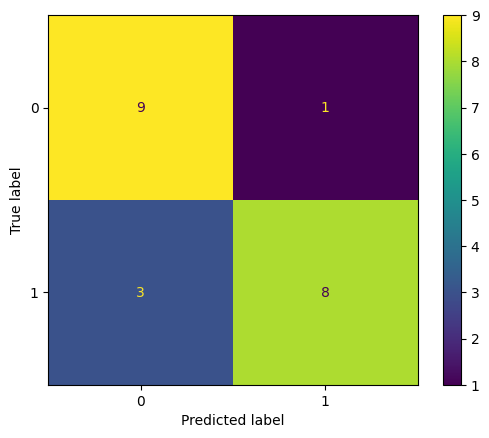

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_log)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()